# Laboratory methods: experiments, measurements and uncertainties
## Experiment no. 4 - measure a tracer concentration with optical methods exploiting the Beer-Lambert law

**Your name(s):**

**Date:**

---
## 1) Objective - Describe the objective of this experiment in your own words (max 150 words).

## 2) Experimental Setup (max 200 words)

## 3) Procedure - Briefly describe the procedure used to collect the data (max 200 words).

## 4) Data collection and storage
Enter the measurements done: 1) size of the channel, 2) concentration of the "n" calibration samples, 3) store and then read the "n" pictures collected (1 per sample)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import tifffile as tiff
from PIL import Image

# Enter pixel size: 3.1 um for XiD (CCD) camera and 5.5 um for XiQ (sCMOS) camera
Px = 0.0055
M = 10
px = Px / M
bit = 8
level = 2**bit - 1
# Enter physical parameters in mm,s
w = 1       # channel width
h = 0.05    # channel thickness
A = w*h     # channel cross sectional area
n = 7       # number of samples

# enter the value sof the prepared calibration concentration
cc = [0.1,0.06,0.03,0.01,0.006,0.003,0.001]
cc = np.array(cc,dtype=float)

filename = f"data_4/im{1:01d}.tif"   # 2-digit format with leading zero
im = Image.open(filename)
im = np.array(im)/level
ny, nx = im.shape

# Enter cropping area
y_min = 200
y_max = ny - y_min
x_min = 200
x_max = nx - x_min

print(f"sample size = {n:.4g}")
print(f"Size of image analysed = {nx:.4g} by {ny:.4g}")
print(f"Size of cropped image = {x_max - x_min:.4g} by {y_max - y_min:.4g}")

I = np.zeros(n)
# Load image
for k in range(0,n):
    filename = f"data_4/im{k+1:01d}.tif"   # 2-digit format with leading zero
    im = Image.open(filename)
    im = np.array(im)/level
    ny, nx = im.shape
    im = im[y_min:y_max, x_min:x_max]
    I[k] = np.mean(im)
    print(f"Intensity, I ={I[k]:.4g}")
    print(f"index, k ={k}")
    
    print(f"Loaded and analyzed {filename}")

df = pd.DataFrame({"Concentration, c [g/mL]": cc, "Light intensity detected, I [A.U.]": I})
df

sample size = 7
Size of image analysed = 2048 by 2048
Size of cropped image = 1648 by 1648
Intensity, I =0.3672
index, k =0
Loaded and analyzed data_4/im1.tif
Intensity, I =0.5598
index, k =1
Loaded and analyzed data_4/im2.tif
Intensity, I =0.6706
index, k =2
Loaded and analyzed data_4/im3.tif
Intensity, I =0.726
index, k =3
Loaded and analyzed data_4/im4.tif
Intensity, I =0.7549
index, k =4
Loaded and analyzed data_4/im5.tif
Intensity, I =0.7711
index, k =5
Loaded and analyzed data_4/im6.tif
Intensity, I =0.9664
index, k =6
Loaded and analyzed data_4/im7.tif


,"Concentration, c [g/mL]","Light intensity detected, I [A.U.]"
0,0.100,0.367151
1,0.060,0.559831
2,0.030,0.670557
3,0.010,0.726047
4,0.006,0.754863
5,0.003,0.771124
6,0.001,0.966412


## 5) Plot results and compute calibration parameter "alpha"

I0 = 0.96641152755522
Calibration parameter =158.7 mL/(g*mm)
Un-attenuated Intensity, H =0.8438 [A.U.]


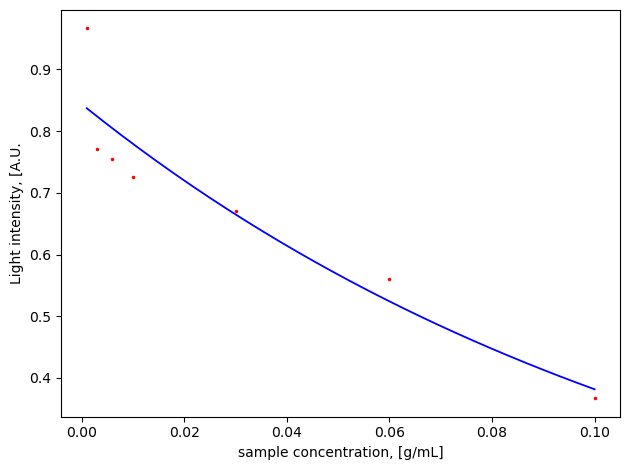

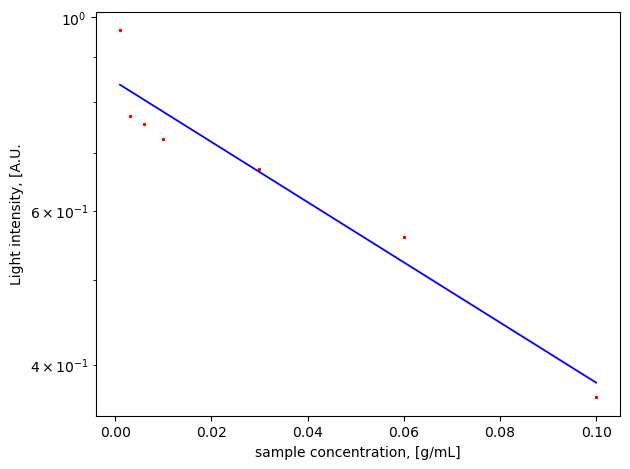

In [4]:
# fit data with Diffusion equation solution
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
import math

# Beer-Lambert law: model for light absorbance - A = alpha
# log(I/I0) = - c h A OR I/I0 = exp(- c h A)
# I0 is the light detected when the sample has ZERO tracer concentration I0 corresponds to c = 0

# model for small concentration (linear)
# c = (im_W - im_c) / (im_W - im_c0)

lw = 1.3
ms = 3;

xdata = cc
ydata = I
I0 = I[n-1]
print("I0 =", I0)

# Model function (MUST take x first, then parameters)
def model(x,params):
    H,p = params
    return H * np.exp(-x * p)
def residuals(params, x, ydata):
    return model(x, params) - ydata
# Initial guess for parameters
p0 = [1,1]

# Perform fit
#popt, pcov = curve_fit(model, xdata, ydata, p0=p0,maxfev=100000)
result = least_squares(residuals, p0, args=(xdata, ydata))
H,p = result.x
A = p/h
print(f"Calibration parameter ={A:.4g} mL/(g*mm)")
print(f"Un-attenuated Intensity, H ={H:.4g} [A.U.]")

c = np.linspace(np.min(cc),np.max(cc),30)
I2 = np.linspace(np.min(I),np.max(I),30)
y = H * np.exp(-c* h * A)

# Plot
plt.figure(1)
plt.plot(cc,I,'r.',linewidth=lw,markersize=ms)
plt.plot(c,y,'b-',linewidth=lw,markersize=ms)
plt.xlabel(r"sample concentration, [g/mL]")
plt.ylabel(r"Light intensity, [A.U.")
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(2)
plt.semilogy(cc,I,'r.',linewidth=lw,markersize=ms)
plt.semilogy(c,y,'b-',linewidth=lw,markersize=ms)
plt.xlabel(r"sample concentration, [g/mL]")
plt.ylabel(r"Light intensity, [A.U.")
plt.grid(False)
plt.tight_layout()
plt.show()


## 7) with the calibration done (alpha and H), measure the concentration of an un-known solution

Intensity, I =0.3632


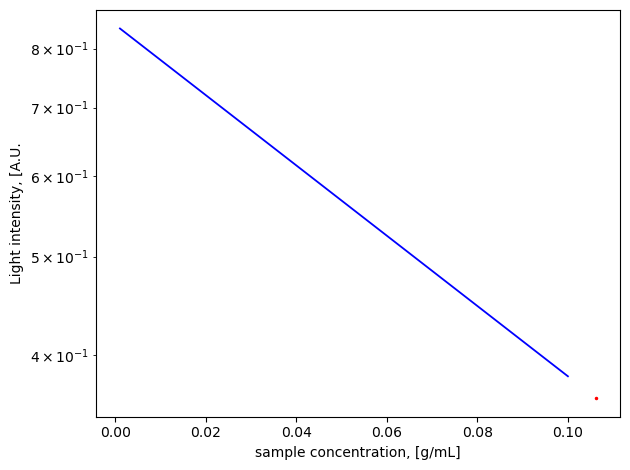

Un-kown solution concentration c =0.1062 g/mL


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import tifffile as tiff
from PIL import Image

# read the image collected for the unknown solution
filename = f"data_4/im_c1.tif"
im = Image.open(filename)
im = np.array(im)/level

im = im[y_min:y_max, x_min:x_max]
Ic = np.mean(im)
print(f"Intensity, I ={Ic:.4g}")

# Beer-Lambert law: model for light absorbance - A = alpha
# log(I/I0) = - c h A OR I/I0 = exp(- c h A)
cu = - 1/(h*A) * np.log(Ic/H)

plt.figure(1)
plt.semilogy(c,y,'b-',linewidth=lw,markersize=ms)
plt.semilogy(cu,Ic,'r.',linewidth=lw,markersize=ms)
plt.xlabel(r"sample concentration, [g/mL]")
plt.ylabel(r"Light intensity, [A.U.")
plt.grid(False)
plt.tight_layout()
plt.show()

print(f"Un-kown solution concentration c ={cu:.4g} g/mL")

## 8) results discussion: comment on the items below
- Does the relationship between the data you collected (Darcy velocity and hydraulic gradient) appear linear?
- The measured value for the Hydraulic conductivity matches the prediction of the KC formula?

---
### IMPORTANT: Before closing the browser
Go to **File → Download → Notebook (.ipynb)** to save your work.
